In [2]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [3]:
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Features and labels
X = iris.data
y = iris.target

# Print info
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Shape:", X.shape)
print("First 3 rows:\n", X[:3])


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Shape: (150, 4)
First 3 rows:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


Task 1:

The dataset contains 150 samples and 3 classes. Each sample has 4 features.

The class distribution is balanced (50 samples per class).

The petal features separate the classes better than the sepal features.


In [4]:
# First 10 rows of X and y
print("First 10 samples (X):\n", X[:10])
print("\nFirst 10 labels (y):\n", y[:10])


First 10 samples (X):
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]

First 10 labels (y):
 [0 0 0 0 0 0 0 0 0 0]


In [5]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))


Class distribution: {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}


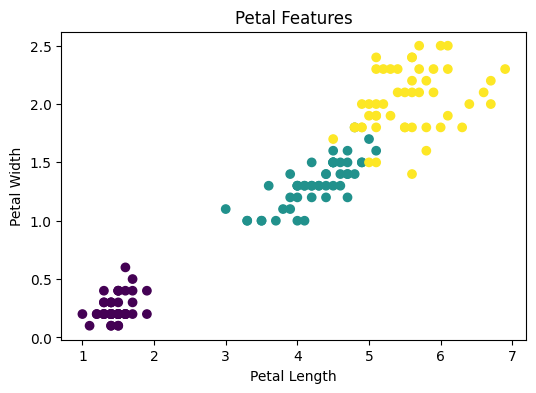

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,2], X[:,3], c=y)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Features")
plt.show()


Task 2:

The data was split into 80% training and 20% testing.

The class distribution remains balanced because stratify=y was used.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (120, 4)
Testing set: (30, 4)


In [10]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)
print("Training class distribution:", dict(zip(unique, counts)))


Training class distribution: {np.int64(0): np.int64(40), np.int64(1): np.int64(40), np.int64(2): np.int64(40)}


Task 3:

Both Decision Tree and KNN models are trained using the training dataset.

Their predictions are compared to see differences in performance.

Changing the value of K in KNN affects the results.


In [11]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_predictions = dt_model.predict(X_test)

print("Decision Tree predictions (first 10):")
print(dt_predictions[:10])

print("Actual labels (first 10):")
print(y_test[:10])


Decision Tree predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]
Actual labels (first 10):
[0 2 1 1 0 1 0 0 2 1]


In [12]:
from sklearn.neighbors import KNeighborsClassifier

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train, y_train)

# Predict
knn_predictions = knn_model.predict(X_test)

print("KNN predictions (first 10):")
print(knn_predictions[:10])


KNN predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


Task 4:

The models are evaluated using accuracy, confusion matrix, and classification report.

These metrics help compare the performance of Decision Tree and KNN.


In [13]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("Decision Tree Accuracy:", dt_accuracy)
print("KNN Accuracy:", knn_accuracy)


Decision Tree Accuracy: 0.9333333333333333
KNN Accuracy: 1.0


In [14]:
from sklearn.metrics import confusion_matrix

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_predictions))


Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

KNN Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [15]:
from sklearn.metrics import classification_report

print("Decision Tree Report:")
print(classification_report(y_test, dt_predictions))

print("\nKNN Report:")
print(classification_report(y_test, knn_predictions))


Decision Tree Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


KNN Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Final Comparison:

In this lab, Decision Tree and K-Nearest Neighbors (KNN) models were compared.
The KNN model achieved higher accuracy (1.00) compared to the Decision Tree (0.93).
The confusion matrix also shows that KNN made no classification errors, while the Decision Tree made a few mistakes.
Although Decision Tree is simple and easy to interpret, KNN performed better on this dataset.
Therefore, KNN is the better model for this problem because it provides more accurate predictions.
